# COSC2753 Assignment 2 - Fashion Intelligence System
## BaseColour Attribute Model

### Objective
No task notebook predicts `baseColour`, but Tasks 1, 2 and 3 all consume it as a metadata
feature for their multi-input models -- Task 1 flagged this as outstanding work. This notebook
trains a standalone image-only classifier for `baseColour` and saves it in the same
load-only format the Pipeline notebook already uses for Tasks 1-3, so the Pipeline notebook
never trains anything itself -- it only loads checkpoints.

Run this notebook after Preprocessing and before the Pipeline notebook.

## Part I - Load the preprocessed data

### What is loaded, and what is rebuilt

Loaded straight from save: the full cleaned split (`train_full.csv` / `val_full.csv`), the
shared image config (`pipeline_config.json`), and the fitted label encoders
(`label_encoders.pkl`). `baseColour` is not one of the tasks in `label_encoders.pkl` --
its own grouping/encoding is fit fresh in Part II below, exactly as it was previously done
inline inside the Pipeline notebook.

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score
from tqdm.auto import tqdm
import joblib
import copy

DATA_DIR = Path("../data/raw/FashionDataset")
OUT_DIR = Path("../data/processed")

TRAIN_CSV = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"

REQUIRED = {
    "config":       OUT_DIR / "pipeline_config.json",
    "train_full":   OUT_DIR / "train_full.csv",
    "val_full":     OUT_DIR / "val_full.csv",
}
missing = {k: v for k, v in REQUIRED.items() if not v.exists()}
for name, path in REQUIRED.items():
    print(f"[{'OK' if path.exists() else 'MISSING':>7}] {name:12s} {path}")
if missing:
    raise FileNotFoundError(
        "Run COSC2753_A2_Preprocessing.ipynb first -- it writes the files above. "
        f"Missing: {list(missing)}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE, NUM_WORKERS = 64, 4
print("Device:", DEVICE)

with open(REQUIRED["config"]) as f:
    config = json.load(f)

RANDOM_STATE = config["random_state"]
IMG_WIDTH = config["image"]["width"]
IMG_HEIGHT = config["image"]["height"]
mean = torch.tensor(config["image"]["normalization_mean"])
std = torch.tensor(config["image"]["normalization_std"])

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"\nSeed {RANDOM_STATE} | images {IMG_HEIGHT}x{IMG_WIDTH} (HxW)")

[     OK] config       ../data/processed/pipeline_config.json
[     OK] train_full   ../data/processed/train_full.csv
[     OK] val_full     ../data/processed/val_full.csv
Device: cuda

Seed 42 | images 80x60 (HxW)


In [2]:
ID_DTYPE = {"id": str}

train_data = pd.read_csv(OUT_DIR / "train_full.csv", dtype=ID_DTYPE)
val_data = pd.read_csv(OUT_DIR / "val_full.csv", dtype=ID_DTYPE)

assert set(train_data["id"]).isdisjoint(set(val_data["id"])), "id overlap between train and val"
print(f"train_full: {train_data.shape}   val_full: {val_data.shape}")

train_full: (28371, 13)   val_full: (9457, 13)


In [3]:
def to_rgb(img):
    """Converts the 249 grayscale ('L' mode) files to 3-channel. A module-level function,
    not a lambda, so the transform stays picklable for DataLoader(num_workers>0)."""
    return img.convert("RGB")

eval_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])

train_transform = T.Compose([
    to_rgb,
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist()),
])


class FashionImageDataset(Dataset):
    """(image, label) pairs. `target_col` names an already-encoded integer column."""

    def __init__(self, dataframe, images_dir, target_col, transform):
        self.data = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        with Image.open(self.images_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im)
        return img, int(row[self.target_col])


def get_weighted_sampler(data, target_col):
    """Inverse-frequency WeightedRandomSampler. Train split only -- never apply to
    validation, which must keep the real class distribution to stay a fair estimate."""
    counts = data[target_col].value_counts()
    weights = data[target_col].map(lambda c: 1.0 / counts[c]).to_numpy(dtype="float64").copy()
    return WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)


_probe_id = train_data["id"].iloc[0]
_probe = eval_transform(Image.open(IMAGES_TRAIN_DIR / f"{_probe_id}.jpg"))
assert _probe.shape == (3, IMG_HEIGHT, IMG_WIDTH), f"unexpected tensor shape {tuple(_probe.shape)}"
print(f"Transform check: image {_probe_id} -> tensor {tuple(_probe.shape)}, "
      f"range [{_probe.min():.2f}, {_probe.max():.2f}]")

Transform check: image 1163 -> tensor (3, 80, 60), range [-3.05, 0.61]


## Part II - BaseColour classification

### a) Preprocessing: rare-class grouping

`baseColour` has a long tail (the rarest colours have as few as 2 rows), so the same
rare-class treatment used elsewhere in this project applies: categories below a train-count
threshold are folded into `Other`. The threshold is set from **train counts only**, consistent
with every other threshold in this project.

In [4]:
BASECOLOUR_MIN_COUNT = 50

vc_colour = train_data['baseColour'].value_counts()
print(f"baseColour categories in train: {len(vc_colour)}")
for thresh in [10, 25, 50, 100]:
    kept = (vc_colour >= thresh).sum()
    rows = vc_colour[vc_colour >= thresh].sum()
    print(f"  threshold={thresh:>4}: {kept:>2}/{len(vc_colour)} categories kept, "
          f"{rows} rows ({rows/len(train_data)*100:.1f}%)")

rare_colours = set(vc_colour[vc_colour < BASECOLOUR_MIN_COUNT].index)
for d in (train_data, val_data):
    d['baseColour_grouped'] = d['baseColour'].where(~d['baseColour'].isin(rare_colours), 'Other')

colour_encoder = LabelEncoder().fit(train_data['baseColour_grouped'])
N_COLOUR = len(colour_encoder.classes_)
train_data['baseColour_enc'] = colour_encoder.transform(train_data['baseColour_grouped'])

# Validation rows whose colour never appears in train can't be scored; none should exist
# after grouping, but check rather than assume.
val_known = val_data['baseColour_grouped'].isin(colour_encoder.classes_)
if (~val_known).sum():
    print(f"Dropping {(~val_known).sum()} val row(s) with an unseen baseColour")
    val_data = val_data[val_known].reset_index(drop=True)
val_data['baseColour_enc'] = colour_encoder.transform(val_data['baseColour_grouped'])

print(f"\nbaseColour classes after grouping: {N_COLOUR}")
print(train_data['baseColour_grouped'].value_counts())

baseColour categories in train: 47
  threshold=  10: 40/47 categories kept, 28338 rows (99.9%)
  threshold=  25: 35/47 categories kept, 28263 rows (99.6%)
  threshold=  50: 31/47 categories kept, 28099 rows (99.0%)
  threshold= 100: 23/47 categories kept, 27491 rows (96.9%)

baseColour classes after grouping: 32
baseColour_grouped
Black           6535
White           3608
Blue            3218
Brown           2234
Grey            1913
Red             1526
Green           1364
Navy Blue       1233
Purple          1027
Pink            1003
Silver           640
Yellow           503
Beige            464
Maroon           336
Gold             333
Orange           326
Other            272
Olive            255
Cream            234
Steel            205
Multi            173
Charcoal         149
Off White        110
Khaki            102
Peach             90
Lavender          85
Grey Melange      81
Tan               77
Teal              76
Magenta           76
Mustard           71
Copper          

### b) Model choice and comparison

Every other task notebook in this project (1, 2, 3) compares a few candidate encoders
before committing to one, so BaseColour gets the same treatment instead of jumping
straight to a single architecture. Four from-scratch image-only encoders are compared,
all wrapped in the same `ImageOnlyClassifier` head:

- `SmallImageEncoder` -- a plain conv stack (Task 2's simplest baseline)
- `ImprovedSmallImageEncoder` -- residual conv blocks (Task 2/3's mid-tier encoder)
- `ResNet18Encoder` -- torchvision's ResNet18 architecture, `weights=None` (from scratch,
  not the ImageNet-pretrained version)
- `SEResidualCNN` -- the SE-residual encoder (Task 1's best from-scratch architecture)

No pretrained encoders here, consistent with the rest of the from-scratch comparisons in
this project.

In [5]:
import torch.nn.functional as F
from torchvision.models import resnet18


# ── SE-Residual encoder (Task 1's best from-scratch architecture) ────────────
class SqueezeExcite(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        s = x.mean(dim=(2, 3))
        s = torch.sigmoid(self.fc2(F.silu(self.fc1(s))))
        return x * s[:, :, None, None]


class SEResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, drop=0.0):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.se = SqueezeExcite(out_ch)
        self.drop = nn.Dropout2d(drop) if drop > 0 else nn.Identity()
        self.shortcut = (nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
                         if (stride != 1 or in_ch != out_ch) else nn.Identity())

    def forward(self, x):
        out = F.silu(self.bn1(x))
        shortcut = self.shortcut(out if not isinstance(self.shortcut, nn.Identity) else x)
        out = self.conv1(out)
        out = self.conv2(F.silu(self.bn2(out)))
        out = self.se(self.drop(out))
        return out + shortcut


class SEResidualCNN(nn.Module):
    """Task 1's name for the encoder. Must match the Pipeline notebook's definition
    exactly -- the state dict loaded there has to match this architecture."""
    def __init__(self, out_dim=128, widths=(32, 64, 128, 256), drop=0.1):
        super().__init__()
        self.stem = nn.Conv2d(3, widths[0], 3, padding=1, bias=False)
        stages, in_ch = [], widths[0]
        for stage_idx, width in enumerate(widths):
            stride = 1 if stage_idx == 0 else 2
            stages.append(SEResidualBlock(in_ch, width, stride=stride, drop=drop))
            stages.append(SEResidualBlock(width, width, stride=1, drop=drop))
            in_ch = width
        self.stages = nn.Sequential(*stages)
        self.norm = nn.BatchNorm2d(in_ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_dim = out_dim
        self.proj = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_ch, out_dim))

    def forward(self, x):
        x = self.stages(self.stem(x))
        x = self.pool(F.silu(self.norm(x))).flatten(1)
        return self.proj(x)


# ── Improved small CNN (residual conv blocks, Task 2/3's mid-tier encoder) ───
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels))

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.act(out + residual)


class ImprovedSmallImageEncoder(nn.Module):
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.stage1 = ConvBlock(3, 32);   self.pool1 = nn.MaxPool2d(2)
        self.stage2 = ConvBlock(32, 64);  self.pool2 = nn.MaxPool2d(2)
        self.stage3 = ConvBlock(64, 128); self.pool3 = nn.MaxPool2d(2)
        self.stage4 = ConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(nn.Dropout(dropout), nn.Linear(256, out_dim),
                                  nn.BatchNorm1d(out_dim), nn.SiLU())

    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        return self.proj(self.global_pool(self.stage4(x)).flatten(1))


# ── Plain small CNN (Task 2's simplest baseline) ─────────────────────────────
class SmallImageEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.out_dim = out_dim
        self.proj = nn.Linear(128, out_dim)

    def forward(self, x):
        return self.proj(self.features(x).flatten(1))


# ── ResNet18, from scratch (weights=None -- NOT the ImageNet-pretrained version) ──
class ResNet18Encoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=None)
        backbone.fc = nn.Identity()
        self.out_dim = out_dim
        self.backbone = backbone
        self.proj = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.proj(self.backbone(x))


class ImageOnlyClassifier(nn.Module):
    """Tasks 2 and 3's image-only wrapper -- same shape the Pipeline notebook expects."""
    def __init__(self, encoder, n_classes):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Linear(encoder.out_dim, n_classes)

    def forward(self, x):
        return self.head(self.encoder(x))


CANDIDATE_ENCODERS = {
    "SmallCNN": SmallImageEncoder,
    "ImprovedSmallCNN": ImprovedSmallImageEncoder,
    "ResNet18 (scratch)": ResNet18Encoder,
    "SEResidualCNN": SEResidualCNN,
}
print(f"{len(CANDIDATE_ENCODERS)} candidate encoders: {list(CANDIDATE_ENCODERS)}")

4 candidate encoders: ['SmallCNN', 'ImprovedSmallCNN', 'ResNet18 (scratch)', 'SEResidualCNN']


### c) Datasets and loaders

Same setup used by every other task notebook: augmentation on train only, a
`WeightedRandomSampler` on train only (validation must keep its real class distribution
to stay a fair estimate).

In [6]:
COMPARE_EPOCHS, COMPARE_PATIENCE = 15, 4

colour_train_ds = FashionImageDataset(train_data, IMAGES_TRAIN_DIR, 'baseColour_enc', train_transform)
colour_val_ds = FashionImageDataset(val_data, IMAGES_TRAIN_DIR, 'baseColour_enc', eval_transform)

colour_sampler = get_weighted_sampler(train_data, 'baseColour_enc')
colour_train_loader = DataLoader(colour_train_ds, batch_size=BATCH_SIZE, sampler=colour_sampler,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
colour_val_loader = DataLoader(colour_val_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

### d) Training each candidate individually

Each candidate trains in its own cell below, calling the shared `train_candidate(name)`
helper. Run whichever cells you want, in any order, skip ones you're not interested in, or
re-run a single cell to retry just that one -- nothing depends on the others having run.
Each finished run adds itself to `candidate_results`, so the comparison and save steps
below just work with however many you've actually trained.

In [7]:
def fit_simple(model, loader_tr, loader_va, name, epochs, patience, lr=3e-4, weight_decay=1e-4):
    """Same recipe as the task notebooks: AdamW, ReduceLROnPlateau, early stopping on
    validation loss, best-checkpoint restore."""
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    best_loss, best_state, best_f1, best_epoch, bad = None, None, None, None, 0
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    for epoch in range(epochs):
        for phase, loader in (('train', loader_tr), ('val', loader_va)):
            training = phase == 'train'
            model.train() if training else model.eval()
            total, n, preds, actual = 0.0, 0, [], []
            with torch.set_grad_enabled(training):
                for imgs, labels in tqdm(loader, desc=f'{name} {epoch+1}/{epochs} {phase}', leave=False):
                    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                    logits = model(imgs)
                    loss = criterion(logits, labels)
                    if training:
                        optimiser.zero_grad(); loss.backward(); optimiser.step()
                    total += loss.item() * labels.size(0); n += labels.size(0)
                    preds.extend(logits.argmax(1).detach().cpu().numpy())
                    actual.extend(labels.cpu().numpy())
            epoch_loss, epoch_f1 = total / n, f1_score(actual, preds, average='macro', zero_division=0)
            history[f'{phase}_loss'].append(epoch_loss); history[f'{phase}_f1'].append(epoch_f1)

        val_loss, val_f1 = history['val_loss'][-1], history['val_f1'][-1]
        print(f'Epoch {epoch+1}/{epochs} - train_loss: {history["train_loss"][-1]:.4f} - '
              f'val_loss: {val_loss:.4f} - val_f1: {val_f1:.4f}')
        scheduler.step(val_loss)
        if best_loss is None or val_loss < best_loss:
            best_loss, best_f1, best_epoch, bad = val_loss, val_f1, epoch + 1, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad += 1
            if bad >= patience:
                print(f'Early stopping at epoch {epoch+1} (best was {best_epoch})')
                break

    model.load_state_dict(best_state)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(name, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train'); axes[1].plot(history['val_f1'], label='Val')
    axes[1].set_title('Macro-F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout(); plt.show()
    print(f'>>> {name}: best epoch {best_epoch}, val_loss={best_loss:.4f}, val_f1={best_f1:.4f}')
    return model, best_f1


def train_candidate(name):
    """Train one candidate encoder and register it in candidate_results. Safe to re-run
    for a single name without re-running the others."""
    torch.manual_seed(RANDOM_STATE)
    encoder_cls = CANDIDATE_ENCODERS[name]
    model = ImageOnlyClassifier(encoder_cls(out_dim=128), N_COLOUR).to(DEVICE)
    model, f1 = fit_simple(model, colour_train_loader, colour_val_loader,
                           f'baseColour {name}', COMPARE_EPOCHS, COMPARE_PATIENCE)
    candidate_results[name] = {'model': model, 'val_macro_f1': f1}
    return model, f1


candidate_results = {}

baseColour SmallCNN 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour SmallCNN 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 2.3674 - val_loss: 2.5937 - val_f1: 0.2064


baseColour SmallCNN 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour SmallCNN 2/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

baseColour SmallCNN 14/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 14/15 - train_loss: 1.1092 - val_loss: 1.5094 - val_f1: 0.3932


baseColour SmallCNN 15/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour SmallCNN 15/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 15/15 - train_loss: 1.0754 - val_loss: 1.5646 - val_f1: 0.3910


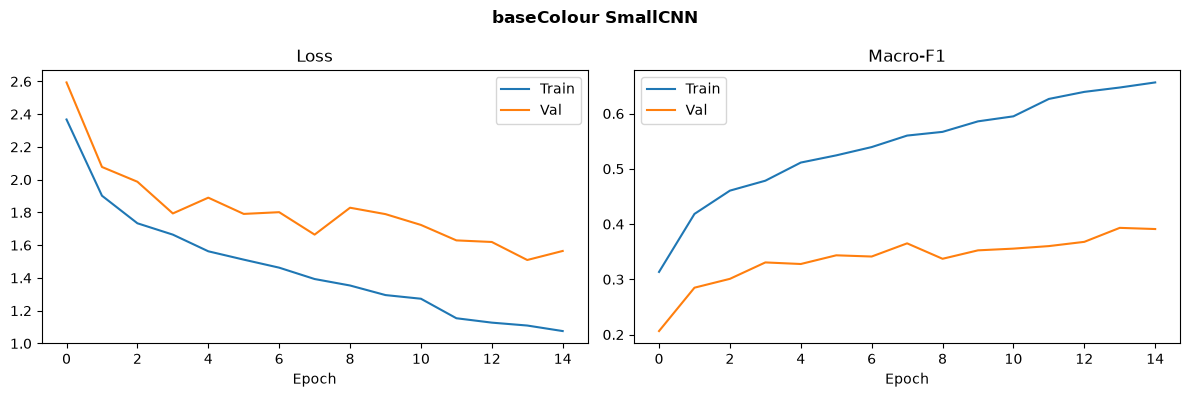

>>> baseColour SmallCNN: best epoch 14, val_loss=1.5094, val_f1=0.3932


(ImageOnlyClassifier(
   (encoder): SmallImageEncoder(
     (features): Sequential(
       (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
       (2): ReLU()
       (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
       (5): ReLU()
       (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
       (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
       (9): ReLU()
       (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
       (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
       (12): ReLU()
       (13): MaxPool2d(kern

In [8]:
train_candidate("SmallCNN")

baseColour ImprovedSmallCNN 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour ImprovedSmallCNN 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 2.2033 - val_loss: 1.9076 - val_f1: 0.2910


baseColour ImprovedSmallCNN 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour ImprovedSmallCNN 2/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

baseColour ImprovedSmallCNN 14/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 14/15 - train_loss: 0.5926 - val_loss: 1.4090 - val_f1: 0.4379


baseColour ImprovedSmallCNN 15/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour ImprovedSmallCNN 15/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 15/15 - train_loss: 0.5579 - val_loss: 1.3630 - val_f1: 0.4310


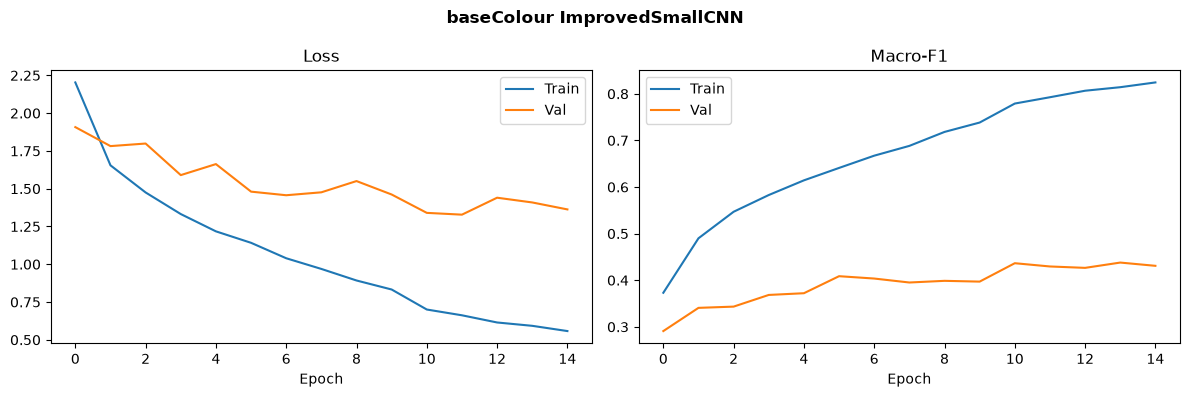

>>> baseColour ImprovedSmallCNN: best epoch 12, val_loss=1.3283, val_f1=0.4296


(ImageOnlyClassifier(
   (encoder): ImprovedSmallImageEncoder(
     (stage1): ConvBlock(
       (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
       (act): SiLU(inplace=True)
       (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
       (shortcut): Sequential(
         (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
         (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
       )
     )
     (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (stage2): ConvBlock(
       (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, mome

In [9]:
train_candidate("ImprovedSmallCNN")

baseColour ResNet18 (scratch) 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour ResNet18 (scratch) 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 1.9728 - val_loss: 3.2093 - val_f1: 0.2090


baseColour ResNet18 (scratch) 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour ResNet18 (scratch) 2/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

baseColour ResNet18 (scratch) 14/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 14/15 - train_loss: 0.3312 - val_loss: 1.6755 - val_f1: 0.3959


baseColour ResNet18 (scratch) 15/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour ResNet18 (scratch) 15/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 15/15 - train_loss: 0.2594 - val_loss: 1.6493 - val_f1: 0.4217
Early stopping at epoch 15 (best was 11)


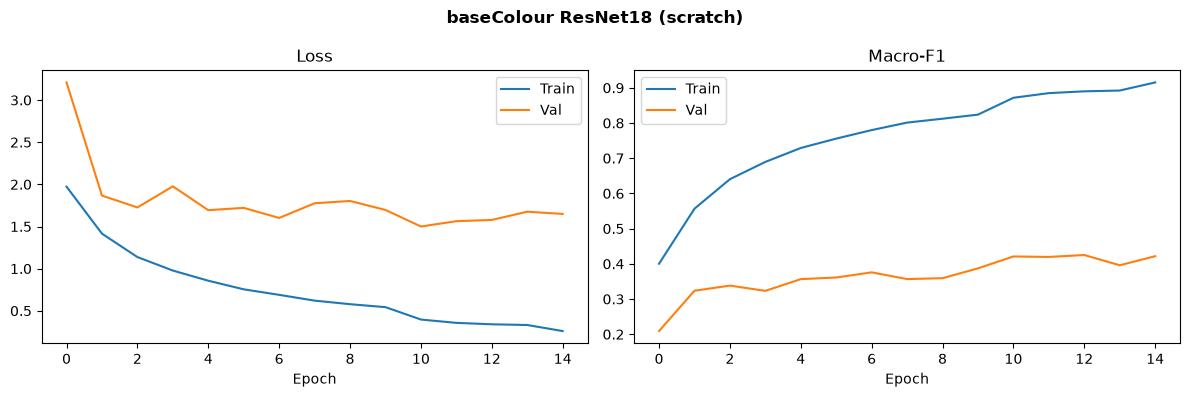

>>> baseColour ResNet18 (scratch): best epoch 11, val_loss=1.5000, val_f1=0.4210


(ImageOnlyClassifier(
   (encoder): ResNet18Encoder(
     (backbone): ResNet(
       (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
       (layer1): Sequential(
         (0): BasicBlock(
           (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
           (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
           (relu): ReLU(inplace=True)
           (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
           (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
         )
         (1): BasicBlock(
           (conv1): Conv2d(64, 64, kernel_size=(3, 3)

In [10]:
train_candidate("ResNet18 (scratch)")

baseColour SEResidualCNN 1/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour SEResidualCNN 1/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 1/15 - train_loss: 2.3730 - val_loss: 2.0455 - val_f1: 0.2563


baseColour SEResidualCNN 2/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour SEResidualCNN 2/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

...

baseColour SEResidualCNN 14/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 14/15 - train_loss: 0.9611 - val_loss: 1.5240 - val_f1: 0.3954


baseColour SEResidualCNN 15/15 train:   0%|          | 0/444 [00:00<?, ?it/s]

baseColour SEResidualCNN 15/15 val:   0%|          | 0/148 [00:00<?, ?it/s]

Epoch 15/15 - train_loss: 0.9243 - val_loss: 1.6744 - val_f1: 0.3783


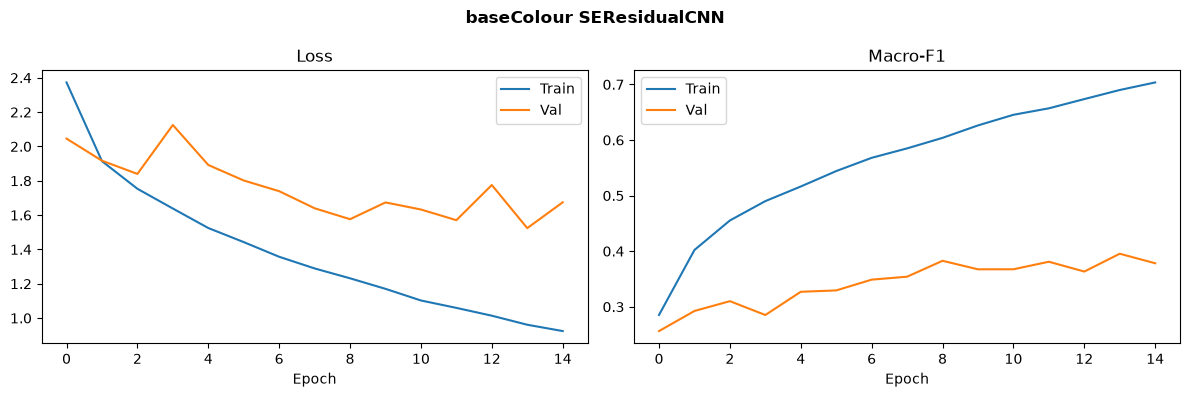

>>> baseColour SEResidualCNN: best epoch 14, val_loss=1.5240, val_f1=0.3954


(ImageOnlyClassifier(
   (encoder): SEResidualCNN(
     (stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (stages): Sequential(
       (0): SEResidualBlock(
         (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
         (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
         (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (se): SqueezeExcite(
           (fc1): Linear(in_features=32, out_features=8, bias=True)
           (fc2): Linear(in_features=8, out_features=32, bias=True)
         )
         (drop): Dropout2d(p=0.1, inplace=False)
         (shortcut): Identity()
       )
       (1): SEResidualBlock(
         (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=

In [11]:
train_candidate("SEResidualCNN")

### e) Comparing what you've trained

Works with however many candidates are in `candidate_results` -- run this after training
any subset above.

Comparison summary:
  ImprovedSmallCNN     val macro-F1 = 0.4296
  ResNet18 (scratch)   val macro-F1 = 0.4210
  SEResidualCNN        val macro-F1 = 0.3954
  SmallCNN             val macro-F1 = 0.3932


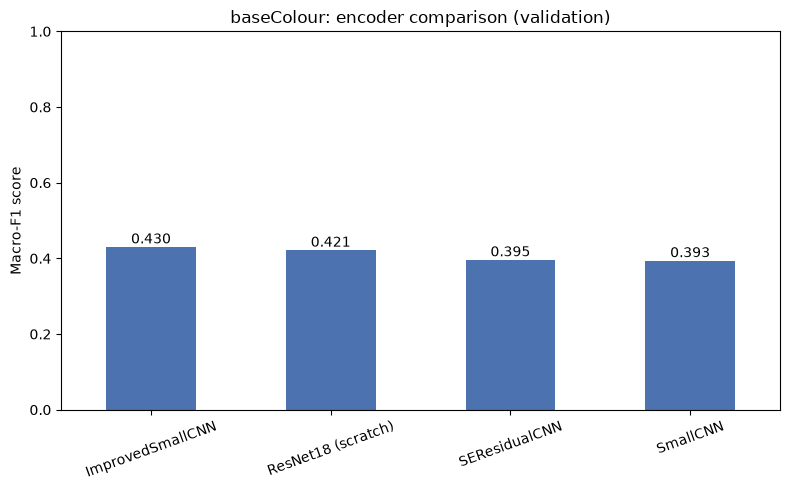

In [12]:
print("Comparison summary:")
for name, r in sorted(candidate_results.items(), key=lambda kv: -kv[1]['val_macro_f1']):
    print(f"  {name:20s} val macro-F1 = {r['val_macro_f1']:.4f}")

comparison_df = pd.Series({name: r['val_macro_f1'] for name, r in candidate_results.items()},
                          name='val_macro_f1').sort_values(ascending=False)

ax = comparison_df.plot(kind='bar', figsize=(8, 5), ylim=(0, 1), rot=20, color='#4C72B0')
ax.set_ylabel('Macro-F1 score')
ax.set_title('baseColour: encoder comparison (validation)')
for i, v in enumerate(comparison_df):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

### f) Choose and save

Set `SELECTED_MODEL` to whichever candidate name you want to keep (must be a key already
in `candidate_results`), or leave it as `None` to auto-pick the highest validation
macro-F1. Saved in the same load-only format Tasks 1-3 already use, to
`../outputs/basecolour_models/`, so the Pipeline notebook can pick it up via `torch.load`
+ `load_state_dict`, exactly like every other Stage 1 attribute model.

In [ ]:
SELECTED_MODEL = None   # e.g. "SEResidualCNN" to force a choice; None = auto-pick best

if SELECTED_MODEL is not None:
    assert SELECTED_MODEL in candidate_results, \
        f"{SELECTED_MODEL!r} hasn't been trained yet -- run its cell above first. " \
        f"Trained so far: {list(candidate_results)}"
    best_name = SELECTED_MODEL
else:
    assert candidate_results, "Train at least one candidate above before saving."
    best_name = max(candidate_results, key=lambda k: candidate_results[k]['val_macro_f1'])

colour_model = candidate_results[best_name]['model']
colour_f1 = candidate_results[best_name]['val_macro_f1']
print(f">>> Saving: {best_name} (val macro-F1 = {colour_f1:.4f})")

OUTPUT_DIR = Path('../outputs') / 'basecolour_models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

encoder_out_dim = 128
torch.save({
    'model_state_dict': colour_model.state_dict(),
    'model_name': f'BaseColour-{best_name}',
    'encoder_class': CANDIDATE_ENCODERS[best_name].__name__,
    'n_classes': N_COLOUR,
    'out_dim': encoder_out_dim,
    'val_macro_f1': float(colour_f1),
    'pretrained': False,
    'min_count': BASECOLOUR_MIN_COUNT,
}, OUTPUT_DIR / 'basecolour_cnn.pt')

joblib.dump(colour_encoder, OUTPUT_DIR / 'basecolour_encoder.joblib')

# Reload check -- confirms the checkpoint reconstructs into a working model, same pattern
# as every other task notebook's save cell.
ckpt = torch.load(OUTPUT_DIR / 'basecolour_cnn.pt', map_location=DEVICE)
reloaded_encoder_cls = CANDIDATE_ENCODERS[best_name]
reloaded = ImageOnlyClassifier(reloaded_encoder_cls(out_dim=ckpt['out_dim']), ckpt['n_classes']).to(DEVICE)
reloaded.load_state_dict(ckpt['model_state_dict'])
print('Reload check: state dict loads cleanly into a fresh model.')
print('Saved:', OUTPUT_DIR / 'basecolour_cnn.pt')
print('Saved:', OUTPUT_DIR / 'basecolour_encoder.joblib')
print(f"\nval_macro_f1 = {colour_f1:.4f}, n_classes = {N_COLOUR}, encoder = {best_name}")